In [476]:
import numpy as np
from numba import jit

In [477]:
@jit
def no_neighbor(M,k,m,n):
    N = M.shape[0]
    A = N//2-1-k  
    
    if M[A+2*m,A+2*n]+M[A+2*m+1,A+2*n]+M[A+2*m,A+2*n+1]+M[A+2*m+1,A+2*n+1]>0:
        return False

    if n==0:
        tmp_w = True
        tmp_e = (M[A+2*m,A+2*(n+1)]+M[A+2*m+1,A+2*(n+1)])==0
    elif n==k:
        tmp_w = (M[A+2*m,A+2*n-1]+M[A+2*m+1,A+2*n-1])==0
        tmp_e = True
    else:
        tmp_w = (M[A+2*m,A+2*n-1]+M[A+2*m+1,A+2*n-1])==0
        tmp_e = (M[A+2*m,A+2*(n+1)]+M[A+2*m+1,A+2*(n+1)])==0

    if m==0:
        tmp_n = True
        tmp_s = (M[A+2*(m+1),A+2*n]+M[A+2*(m+1),A+2*n+1])==0
    elif m==k:
        tmp_n = (M[A+2*m-1,A+2*n]+M[A+2*m-1,A+2*n+1])==0
        tmp_s = True
    else:
        tmp_n = (M[A+2*m-1,A+2*n]+M[A+2*m-1,A+2*n+1])==0
        tmp_s = (M[A+2*(m+1),A+2*n]+M[A+2*(m+1),A+2*n+1])==0

    return tmp_s and tmp_e and tmp_w and tmp_n


@jit
def update(w,x,y,z,ew,ex,ey,ez):
    Ixy = ex+ey
    Iwz = ew+ez

    #####
    # Good place for checking stability!
    #####

    if Ixy>Iwz:
        return 1/w,y/(w*z),x/(w*z),1/z,-ew,ey-Iwz,ex-Iwz,-ez
    elif Ixy<Iwz:
        return z/(x*y),1/x,1/y,w/(x*y),ez-Ixy,-ex,-ey,ew-Ixy
    else:
        tmp = z*w+x*y
        return z/tmp, y/tmp, x/tmp, w/tmp, ez-Ixy,ey-Ixy,ex-Ixy,ew-Ixy

@jit
def comp_prop(w,x,y,z,ew,ex,ey,ez):
    Ixy = ex+ey
    Iwz = ew+ez
    if Ixy>Iwz:
        return 1.
    elif Ixy < Iwz:
        return 0.
    else:
        return w*z/(w*z+x*y)

@jit
def reduce_weight(W):
    K = W.shape[0] // 2
    C = W.copy()+ (W==0)
    E = 1*(W == 0) #.astype(int)
    for k in range(K-1):
        for m in range(K-k):
            for n in range(K-k):
                w ,x ,y ,z  = C[k+2*m,k+2*n],C[k+2*m,k+2*n+1],C[k+2*m+1,k+2*n],C[k+2*m+1,k+2*n+1]
                ew,ex,ey,ez = E[k+2*m,k+2*n],E[k+2*m,k+2*n+1],E[k+2*m+1,k+2*n],E[k+2*m+1,k+2*n+1]
                
                w,x,y,z,ew,ex,ey,ez = update(w,x,y,z,ew,ex,ey,ez)
                C[k+2*m,k+2*n],C[k+2*m,k+2*n+1],C[k+2*m+1,k+2*n],C[k+2*m+1,k+2*n+1] = w,x,y,z
                E[k+2*m,k+2*n],E[k+2*m,k+2*n+1],E[k+2*m+1,k+2*n],E[k+2*m+1,k+2*n+1] = ew,ex,ey,ez
    return C,E

@jit
def shuffling(C0,E0):
    C = C0.copy()
    E = E0.copy()
    N = C.shape[0]
    M = np.zeros((N,N),dtype=np.int8)

    # Initiate
    A = N//2-1
    w,x,y,z     = C[A,A],C[A,A+1],C[A+1,A],C[A+1,A+1]
    ew,ex,ey,ez = E[A,A],E[A,A+1],E[A+1,A],E[A+1,A+1]
    prob = comp_prop(w,x,y,z,ew,ex,ey,ez)
    if np.random.random()<prob:
        M[A,A],M[A+1,A+1]= 1,1
        M[A,A+1],M[A+1,A]= 0,0
    else:
        M[A,A],M[A+1,A+1]= 0,0
        M[A,A+1],M[A+1,A]= 1,1

    
    for k in range(1,N//2):
        A = N//2-1-k   

        # destruction + flip (+ reconstruct)
        for m in range(k+1):
            for n in range(k+1):
                # reconstruct
                w,x,y,z     = C[A+2*m,A+2*n],C[A+2*m,A+2*n+1],C[A+2*m+1,A+2*n],C[A+2*m+1,A+2*n+1]
                ew,ex,ey,ez = E[A+2*m,A+2*n],E[A+2*m,A+2*n+1],E[A+2*m+1,A+2*n],E[A+2*m+1,A+2*n+1]
                
                w,x,y,z,ew,ex,ey,ez = update(w,x,y,z,ew,ex,ey,ez)
                C[A+2*m,A+2*n],C[A+2*m,A+2*n+1],C[A+2*m+1,A+2*n],C[A+2*m+1,A+2*n+1] = w,x,y,z
                E[A+2*m,A+2*n],E[A+2*m,A+2*n+1],E[A+2*m+1,A+2*n],E[A+2*m+1,A+2*n+1] = ew,ex,ey,ez

                # destruction + flip
                tmp = M[A+2*m,A+2*n]+M[A+2*m+1,A+2*n]+M[A+2*m,A+2*n+1]+M[A+2*m+1,A+2*n+1]
                if tmp>1:
                    M[A+2*m,A+2*n],M[A+2*m+1,A+2*n],M[A+2*m,A+2*n+1],M[A+2*m+1,A+2*n+1]=0,0,0,0
                elif tmp == 1:
                    M[A+2*m,A+2*n],M[A+2*m+1,A+2*n+1]=M[A+2*m+1,A+2*n+1],M[A+2*m,A+2*n]
                    M[A+2*m,A+2*n+1],M[A+2*m+1,A+2*n]=M[A+2*m+1,A+2*n],M[A+2*m,A+2*n+1]

        for m in range(k+1):
            for n in range(k+1):
                if no_neighbor(M,k,m,n):
                    w,x,y,z     = C[A+2*m,A+2*n],C[A+2*m,A+2*n+1],C[A+2*m+1,A+2*n],C[A+2*m+1,A+2*n+1]
                    ew,ex,ey,ez = E[A+2*m,A+2*n],E[A+2*m,A+2*n+1],E[A+2*m+1,A+2*n],E[A+2*m+1,A+2*n+1]
                    prob = comp_prop(w,x,y,z,ew,ex,ey,ez)

                    if np.random.random()<prob:
                        M[A+2*m,A+2*n],M[A+2*m+1,A+2*n+1]= 1,1
                        M[A+2*m,A+2*n+1],M[A+2*m+1,A+2*n]= 0,0
                    else:
                        M[A+2*m,A+2*n],M[A+2*m+1,A+2*n+1]= 0,0
                        M[A+2*m,A+2*n+1],M[A+2*m+1,A+2*n]= 1,1
    return M



In [478]:
from RandomTilingsV1.weight_hexagon import weight_hexagon
from RandomTilingsV1.draw_lozenges import draw_lozenges
from RandomTilingsV1.algorithm_reduction_weight import algorithm_reduction_weight
from RandomTilingsV1.shuffling import shuffling as shuffling0

from RandomTilingsV1.weight_aztec import weight_aztec
from RandomTilingsV1.draw_dominos import draw_dominos

def draw0(n,w,edge=0,paths=False,dots=False,coloring='standard',dpi=200,show_figure=True):
    w = w.astype(float)
    edge = str(edge)
    W = weight_aztec(n,w)
    C = algorithm_reduction_weight(W)
    M = shuffling0(C)
    print(M.shape)
    fig = draw_dominos(M,False,edge,paths,dots,False,'standard',False,dpi,show_figure)
    return fig


def draw(n,w,edge=0,paths=False,dots=False,coloring='standard',dpi=200,show_figure=True):
    w = w.astype(float)
    edge = str(edge)
    W    = weight_aztec(n,w)

    C,E  = reduce_weight(W)
    M    = shuffling(C,E)

    fig  = draw_dominos(M.astype(int),False,edge,paths,dots,False,'standard',False,dpi,show_figure)
    return fig

def draw_hexagon0(n,w,a=1,b=1,c=1,skewed_grid=False,edge=0,paths=False,dots=False,coloring='standard',dpi=200,show_figure=True):
    w = w.astype(float)
    edge = str(edge)
    W = weight_hexagon(n,w,a,b,c)
    C = algorithm_reduction_weight(W)
    M = shuffling0(C)
    print(M.shape)
    fig = draw_lozenges(n,M.astype(int),False,a,b,c,skewed_grid,edge,paths,dots,coloring,False,dpi,show_figure)
    return fig


def draw_hexagon(n,w,a=1,b=1,c=1,skewed_grid=False,edge=0,paths=False,dots=False,coloring='standard',dpi=200,show_figure=True):
    w = w.astype(float)
    edge = str(edge)
    W    = weight_hexagon(n,w,a,b,c)

    C,E  = reduce_weight(W)
    M    = shuffling(C,E)
    return 
    fig  = draw_lozenges(n,M.astype(int),False,a,b,c,skewed_grid,edge,paths,dots,coloring,False,dpi,show_figure)
    return fig

In [479]:
n = 200                     # Side length

# Constructing the doubly periodic weighting from arXiv:2412.03115
alpha1 = 0.3
alpha2 = 0.3
w = np.array([[1,1,1],[1,1,1],[1,1,1],[1/alpha1,alpha2,
            alpha1/alpha2],[1,1,1],[alpha1,1/alpha2,alpha2/alpha1]])

_=draw_hexagon(n,w,show_figure=False,dpi=1)

KeyboardInterrupt: 

array([[1., 1.],
       [1., 1.]])

In [ ]:
import RandomTilings as RT

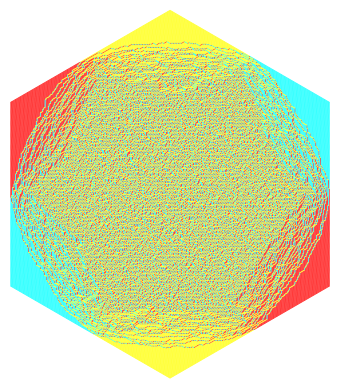

In [ ]:
H = RT.Hexagon(n,w)
H.shuffle()
H.plot()

In [ ]:
H.get_M().shape

(10, 10)

# Timings

In [ ]:
import RandomTilings as RT
import matplotlib.pyplot as plt
from tqdm import trange
from time import time

In [ ]:
def test_hexagon(n,w,a=1,b=1,c=1):
    w = w.astype(float)
    W    = weight_hexagon(n,w,a,b,c)

    C,E  = reduce_weight(W)
    M    = shuffling(C,E)

In [480]:
T1 = []
T2 = []

N_min = 100
N_max = 200
reps  = 1

w = np.array([[1.]])
for n  in trange(N_min,N_max+1):
    t1 = time()
    for _ in range(reps):
        H = RT.Hexagon(n,w)
        H.shuffle()
    T1 += [(time()-t1)/reps]

    t1 = time()
    for _ in range(reps):
        test_hexagon(n,w)
    T2 += [(time()-t1)/reps]

100%|██████████| 101/101 [07:40<00:00,  4.56s/it]


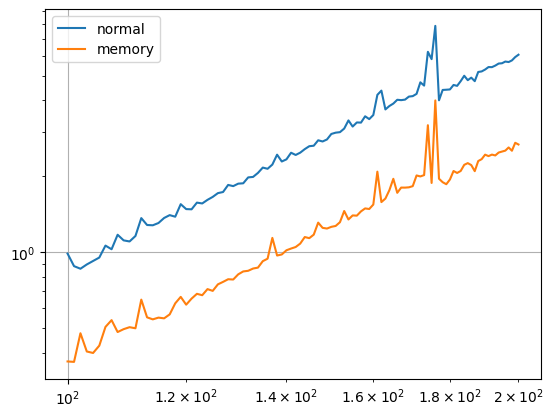

In [481]:
plt.plot(range(N_min,N_max+1),T1,label='normal')
plt.plot(range(N_min,N_max+1),T2,label='memory')


plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.grid()
plt.show()

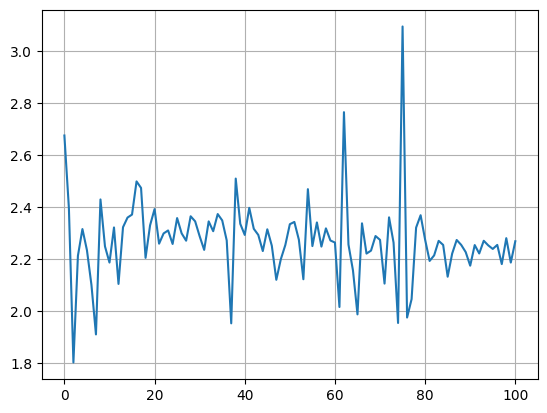

In [483]:
T1 = np.array(T1)
T2 = np.array(T2)
plt.plot(T1/T2)
plt.grid()



In [490]:
def sumation(N):
    res = 0
    for t in range(N+1):
        for _ in range(N+1):
            res += 1
    return res

@jit("(int64,)")
def sumation_jit(N):
    res = 0
    for t in range(N+1):
        for _ in range(N+1):
            res += 1
    return res

In [ ]:
N = 100
%timeit sumation(N)
%timeit sumation_jit(N)

332 μs ± 9.47 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
158 ns ± 2.92 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


In [495]:

sumation_jit(np.int32(5))

36

[]

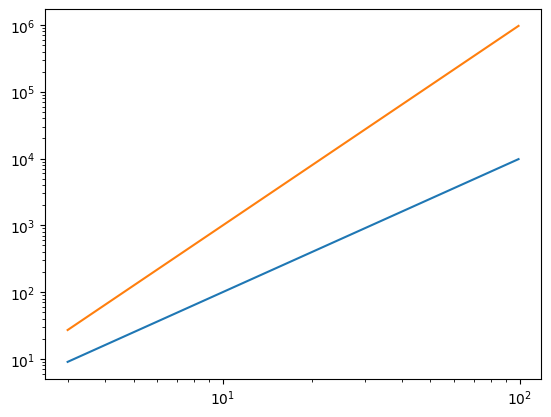

In [ ]:
N = 100
t = np.arange(3,N)
x = np.arange(3,N)**2
y = np.arange(3,N)**3

plt.plot(t,x)
plt.plot(t,y)
plt.loglog()